#  SmartInbox – SMS Spam Detection ML Pipeline

## 0 · Install & Import Dependencies

In [1]:
%pip install --quiet scikit-learn>=1.4.0
%pip install --quiet numpy>=1.26.0
%pip install --quiet pandas>=2.1.0
%pip install --quiet scipy>=1.12.0
%pip install --quiet nltk>=3.8.0
%pip install --quiet imbalanced-learn>=0.12.0
%pip install --quiet matplotlib>=3.8.0
%pip install --quiet seaborn>=0.13.0
print(" All dependencies installed.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
 All dependencies installed.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 · Core Imports

In [2]:
%matplotlib inline
import os, json, pickle, logging, random, re, string, uuid
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MaxAbsScaler

print("✅ Core imports done.")

✅ Core imports done.


## 2 · Utilities (`utils.py`)
Shared logging helpers, file-I/O (pickle / JSON), reproducibility, and path management.

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
ROOT_DIR      = Path(".").resolve()          # ml/ working directory
MODELS_DIR    = ROOT_DIR / "models"
ARTIFACTS_DIR = ROOT_DIR / "artifacts"
LOGS_DIR      = ROOT_DIR / "logs"
DATA_DIR      = ROOT_DIR / "data"

def ensure_dirs(*dirs: Path) -> None:
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)

ensure_dirs(MODELS_DIR, ARTIFACTS_DIR, LOGS_DIR)
print("Directories ready:", MODELS_DIR, ARTIFACTS_DIR, LOGS_DIR)

Directories ready: C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\models C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\logs


# Logger 
> it helps us to get a custom logging utility function that creates and configures a reusuable logger

Adds two handlers:

    StreamHandler → outputs logs to the console.

    FileHandler → saves logs to a file for persistent tracking.

In [4]:
# ── Logging ──────────────────────────────────────────────────────────────────
def get_logger(name: str, level: int = logging.INFO) -> logging.Logger:
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger
    logger.setLevel(level)
    fmt = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(ch)
    log_file = LOGS_DIR / f"{name}.log"
    fh = logging.FileHandler(log_file, encoding="utf-8")
    fh.setFormatter(fmt)
    logger.addHandler(fh)
    return logger

logger = get_logger("notebook")
logger.info("Logger initialised.")

2026-03-22 10:10:41 | INFO     | notebook | Logger initialised.


# Reproducibility 
It would fixing the random seed across different libraries

In [5]:
# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)
logger.info("Random seed set to 42.")

2026-03-22 10:10:41 | INFO     | notebook | Random seed set to 42.


# Serialisation helpers
It helps us to make functions for serialization allowing python objects to be saved and loaded using Pickle and JSON 

In [6]:
# ── Serialisation helpers ────────────────────────────────────────────────────
def save_pickle(obj: Any, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_pickle(path: Path) -> Any:
    with open(path, "rb") as f:
        return pickle.load(f)

def _json_default(obj: Any) -> Any:
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serialisable")

def save_json(data: Dict, path: Path, indent: int = 2) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=indent, default=_json_default)

def load_json(path: Path) -> Dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def utc_now_iso() -> str:
    return datetime.now(tz=timezone.utc).isoformat()

print("✅ Serialisation helpers defined.")

✅ Serialisation helpers defined.


# Dataset Loader
function `load_sms_data` helps us to load and standarize the dataset

In [7]:
# ── Dataset loader ───────────────────────────────────────────────────────────
def load_sms_data(path: Optional[Path] = None) -> pd.DataFrame:
    """
    Load the SMSSpamCollection TSV or spam_dataset.csv.
    Returns a DataFrame with columns: id, text, label, timestamp, user_id.
    """
    if path is None:
        # try canonical name first, then CSV fallback
        tsv = DATA_DIR / "SMSSpamCollection"
        csv = DATA_DIR / "spam_dataset.csv"
        path = tsv if tsv.exists() else csv

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found at {path}")

    if path.suffix == ".csv":
        df = pd.read_csv(path, encoding="utf-8")
        # Normalise column names: expect 'label'/'text' or 'spam'/'message'
        df.columns = [c.strip().lower() for c in df.columns]
        if "message" in df.columns and "text" not in df.columns:
            df.rename(columns={"message": "text"}, inplace=True)
        if "spam" in df.columns and "label" not in df.columns:
            df.rename(columns={"spam": "label"}, inplace=True)
        if "category" in df.columns and "label" not in df.columns:
            df["label"] = (df["category"].str.strip().str.lower() == "spam").astype(int)
            df.drop(columns=["category"], inplace=True)
        df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    else:
        df = pd.read_csv(path, sep="\t", header=None,
                         names=["_raw_label", "text"], encoding="utf-8")
        df["label"] = (df["_raw_label"].str.strip().str.lower() == "spam").astype(int)
        df.drop(columns=["_raw_label"], inplace=True)

    n = len(df)
    base_ts = datetime(2024, 1, 1, tzinfo=timezone.utc).timestamp()
    df["id"]        = [str(uuid.uuid4()) for _ in range(n)]
    df["timestamp"] = [
        datetime.fromtimestamp(base_ts + i * 60, tz=timezone.utc).isoformat()
        for i in range(n)
    ]
    df["user_id"] = [f"user_{(i % 500) + 1:04d}" for i in range(n)]
    df = df[["id", "text", "label", "timestamp", "user_id"]]
    return df

print(" load_sms_data() defined.")

 load_sms_data() defined.


## 3 · Load & Explore Dataset

In [8]:
df = load_sms_data()
print(f"Dataset shape : {df.shape}")
print(f"Spam  (1)     : {df['label'].sum():,}")
print(f"Ham   (0)     : {(df['label']==0).sum():,}")
print(f"Spam ratio    : {df['label'].mean():.2%}")
df.head()

Dataset shape : (100, 5)
Spam  (1)     : 60
Ham   (0)     : 40
Spam ratio    : 60.00%


,id,text,label,timestamp,user_id
0,4e587877-e001-456f-87ca-e02e94b7f22a,Win free money now!!! Call this number,1,2024-01-01T00:00:00+00:00,user_0001
1,12734a33-526f-4b4a-b574-221454b1e8d6,"Hey, how are you?",0,2024-01-01T00:01:00+00:00,user_0002
2,fa0a13de-2e9c-48d9-8723-b82bda8e1389,Urgent: Claim your prize!!!,1,2024-01-01T00:02:00+00:00,user_0003
3,fbbe8f09-cf72-428e-a85e-83e07c720930,Meeting at 5 pm for the project,0,2024-01-01T00:03:00+00:00,user_0004
4,4d1f0abb-69f5-4b80-9662-8ffded942a16,Get cheap meds fast online,1,2024-01-01T00:04:00+00:00,user_0005


# Visualization of SPAM & HAM and Message Length


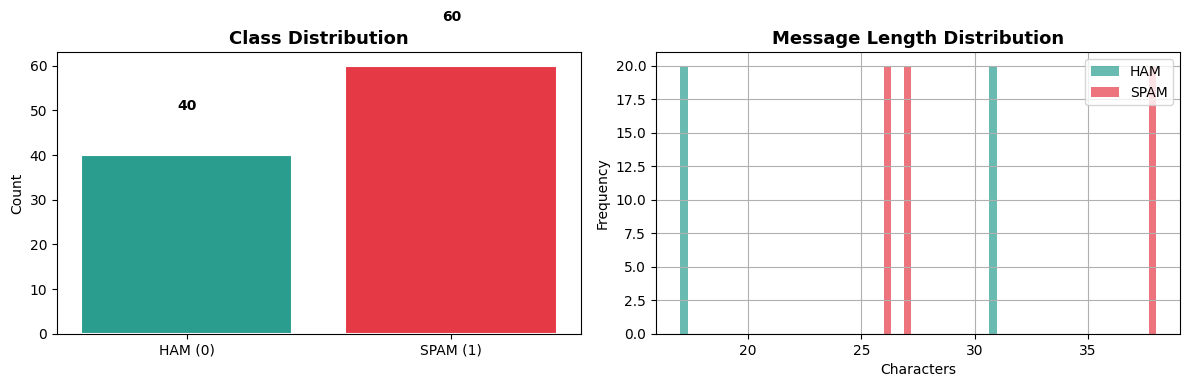

✅ Visualisation saved.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define ROOT_DIR and ARTIFACTS_DIR for self-containment
ROOT_DIR      = Path(".").resolve()
ARTIFACTS_DIR = ROOT_DIR / "artifacts"

# Ensure ARTIFACTS_DIR exists
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Class distribution visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["label"].value_counts()
axes[0].bar(["HAM (0)", "SPAM (1)"], [counts.get(0,0), counts.get(1,0)],
            color=["#2A9D8F", "#E63946"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

df["msg_len"] = df["text"].str.len()
df[df["label"]==0]["msg_len"].hist(ax=axes[1], color="#2A9D8F", alpha=0.7, bins=40, label="HAM")
df[df["label"]==1]["msg_len"].hist(ax=axes[1], color="#E63946", alpha=0.7, bins=40, label="SPAM")
axes[1].set_title("Message Length Distribution", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Characters"); axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisation saved.")

## 4 · Preprocessing Pipeline (`preprocessing.py`)
Stages: clean text → remove stopwords → lemmatise → TF-IDF (word + char) + numeric features (length, specials, digits)

In [ ]:
import nltk
import string # Added this import
resources = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]
for r in resources:
    nltk.download(r, quiet=True, raise_on_error=False)

from nltk.corpus   import stopwords         # Removiing unnecassary words
from nltk.stem     import WordNetLemmatizer # Convert to base form
from nltk.tokenize import word_tokenize     # Splitting text into tokens

_STOP_WORDS  = set(stopwords.words("english"))
_LEMMATIZER  = WordNetLemmatizer()
_PUNCT_TABLE = str.maketrans("", "", string.punctuation) # remove punctuation

print(" NLTK resources loaded.")

 NLTK resources loaded.


# Text Preprocessing 

>A text preprocessing pipeline that cleans input text, removes punctuation and stopwords, tokenizes words, and applies lemmatization to convert them into their base form, producing a normalized string suitable for machine learning models like TF-IDF.

In [ ]:
import re

# Text cleaning functions 
def clean_text(text: str) -> str:
    """Lower-case → remove punctuation → strip extra whitespace."""
    text = str(text).lower()
    text = text.translate(_PUNCT_TABLE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_and_lemmatize(text: str) -> List[str]:
    """Tokenise → remove stopwords → lemmatise."""
    tokens = word_tokenize(text)
    return [
        _LEMMATIZER.lemmatize(tok)
        for tok in tokens
        if tok not in _STOP_WORDS and tok.isalpha()
    ]

def preprocess_text(text: str) -> str:
    """Full pipeline → clean string ready for TF-IDF."""
    return " ".join(tokenize_and_lemmatize(clean_text(text)))

# Example 
sample = "Congratulations! You've WON £1000 FREE cash. Claim NOW!"
print("Original :", sample)
print("Cleaned  :", preprocess_text(sample))

Original : Congratulations! You've WON £1000 FREE cash. Claim NOW!
Cleaned  : congratulation youve free cash claim


# Numeric Features 

In [ ]:
#  Numeric feature extractor 

def extract_numeric_features(texts: pd.Series) -> np.ndarray:
    """Return (n, 3) array: [msg_length, special_char_count, digit_count]."""
    lengths  = texts.str.len().fillna(0).values
    specials = texts.apply(
        lambda t: sum(1 for c in str(t) if not c.isalnum() and not c.isspace())
    ).values
    digits = texts.apply(lambda t: sum(c.isdigit() for c in str(t))).values
    return np.column_stack([lengths, specials, digits]).astype(np.float64)

#  Sklearn-compatible transformers 

class TextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return pd.Series(X).apply(preprocess_text).tolist()

class NumericFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        return extract_numeric_features(pd.Series(X))

print("✅ Preprocessing helpers defined.")

✅ Preprocessing helpers defined.


# TF-IDF 

In [ ]:
#  TF-IDF vectorizer For Words --> captures the meaning 
def build_tfidf_word(max_features: int = 30_000) -> TfidfVectorizer:
    """Word-level TF-IDF (unigrams + bigrams)."""
    return TfidfVectorizer(
        analyzer="word", ngram_range=(1, 2),
        max_features=max_features, sublinear_tf=True,
        min_df=2, token_pattern=r"(?u)\b[a-zA-Z]\w+\b",
    )

# TF-IDF vectorizer For Char --> Handles the spelling trick
def build_tfidf_char(max_features: int = 20_000) -> TfidfVectorizer:
    """Character n-gram TF-IDF (3–5 grams)."""
    return TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5),
        max_features=max_features, sublinear_tf=True, min_df=2,
    )

print("✅ TF-IDF factories defined.")

✅ TF-IDF factories defined.


In [ ]:
# ── SMSFeaturePipeline ────────────────────────────────────────────────────────
class SMSFeaturePipeline:
   # Intialization 
   # for the words char and normalizes numeric features 
    def __init__(self, word_max_features=30_000, char_max_features=20_000):
        self.word_tfidf = build_tfidf_word(word_max_features)
        self.char_tfidf = build_tfidf_char(char_max_features)
        self.scaler     = MaxAbsScaler()
        self._fitted    = False

    # Cleaning helper 
        # Cleaning 
        # Tokenization 
        # Lemmatization

    def _clean_series(self, texts) -> List[str]:
        return [preprocess_text(t) for t in texts]

    # Training Phase 

    def fit_transform(self, texts, y=None):
        raw  = pd.Series(texts)                                             # Pandas series
        clean = self._clean_series(raw)
        word_feats = self.word_tfidf.fit_transform(clean)                   # word TF-IDF
        char_feats = self.char_tfidf.fit_transform(clean)                   # char TF-IDF
        num_feats  = extract_numeric_features(raw)                          # numeric scaling 
        num_sparse = csr_matrix(self.scaler.fit_transform(num_feats))       # CSR format for sparse matrix
        combined = hstack([word_feats, char_feats, num_sparse], format="csr")
        self._fitted = True
        logger.info("Feature matrix shape: %s", combined.shape)
        return combined

    # Testing Phase 
    def transform(self, texts):
        if not self._fitted:
            raise RuntimeError("Pipeline not fitted. Call fit_transform() first.")
        raw   = pd.Series(texts)
        clean = self._clean_series(raw)
        word_feats = self.word_tfidf.transform(clean)
        char_feats = self.char_tfidf.transform(clean)
        num_feats  = extract_numeric_features(raw)
        num_sparse = csr_matrix(self.scaler.transform(num_feats))
        return hstack([word_feats, char_feats, num_sparse], format="csr")

    def save(self, path=None):
        p = Path(path) if path else ARTIFACTS_DIR / "feature_pipeline.pkl"
        save_pickle(self, p)
        logger.info("Feature pipeline saved → %s", p)

    @classmethod
    def load(cls, path=None):
        p = Path(path) if path else ARTIFACTS_DIR / "feature_pipeline.pkl"
        return load_pickle(p)

    @property
    def feature_names(self) -> List[str]:
        word = self.word_tfidf.get_feature_names_out().tolist()
        char = [f"char_{n}" for n in self.char_tfidf.get_feature_names_out()]
        num  = ["feat_msg_length", "feat_special_chars", "feat_digit_count"]
        return word + char + num

print("✅ SMSFeaturePipeline defined.")

✅ SMSFeaturePipeline defined.


## 5 · Custom Threshold & Metric Utilities (`threshold.py`)
Manual ROC/PR curve computation, AUC via trapezoidal rule, and the `ThresholdOptimiser` class.

Receiver Operating Characteristics (ROC) graph is a visual map that shows how well a decision-making model balances its successes against its mistakes

>The Y-axis is the True Positive Rate (`hit rate`): This measures how often the model correctly identifies what it is looking for 

>The X-axis is the False Positive Rate (`false alarm rate`): This measures how often the model incorrectly triggers an alarm for a normal item 

In [ ]:

# ROC (Receiver Operating Characteristic) 
    # Performance of a binary classification model at various threshold settings

def compute_roc_curve(y_true, y_prob) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    sort_idx = np.argsort(-y_prob)
    y_sorted = y_true[sort_idx]
    prob_sorted = y_prob[sort_idx]
    n_pos = int(y_true.sum())
    n_neg = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError("ROC curve requires at least one positive and one negative sample.")
    tpr_list = [0.0]; fpr_list = [0.0]; thr_list = [prob_sorted[0] + 1e-10]
    tp = fp = 0; prev_thresh = np.inf
    for i, (score, label) in enumerate(zip(prob_sorted, y_sorted)):
        if score != prev_thresh and i > 0:
            tpr_list.append(tp / n_pos); fpr_list.append(fp / n_neg); thr_list.append(score)
        if label == 1: tp += 1
        else:          fp += 1
        prev_thresh = score
    tpr_list.append(tp / n_pos); fpr_list.append(fp / n_neg); thr_list.append(0.0)
    return np.array(fpr_list), np.array(tpr_list), np.array(thr_list)

print("✅ compute_roc_curve() defined.")

✅ compute_roc_curve() defined.


# Precision–Recall curve  
 How good is the model at predicting the positive class

 X-Axis = Precision 
 Y-Axis = Recall 

In [ ]:
#  PR curve (Precision-Recall Curve)
def compute_pr_curve(y_true, y_prob) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Precision-Recall curve computed manually."""
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    sort_idx = np.argsort(-y_prob)
    y_sorted = y_true[sort_idx]; prob_sorted = y_prob[sort_idx]
    n_pos = int(y_true.sum())
    prec_list: List[float] = []; rec_list: List[float] = []; thr_list: List[float] = []
    tp = fp = 0
    for i, (score, label) in enumerate(zip(prob_sorted, y_sorted), start=1):
        if label == 1: tp += 1
        else:          fp += 1
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / n_pos     if n_pos > 0      else 0.0
        prec_list.append(prec); rec_list.append(rec); thr_list.append(score)
    prec_list.append(1.0); rec_list.append(0.0)
    return np.array(prec_list), np.array(rec_list), np.array(thr_list)

print("✅ compute_pr_curve() defined.")

✅ compute_pr_curve() defined.


In [ ]:
# AUC trapezoidal  --> Definte Intergral
#       Trapezodial is a numerical Integration in the definite Integral for the Area under the Curve

def compute_auc_trapezoidal(x: np.ndarray, y: np.ndarray) -> float:
    """Area under curve via trapezoidal rule. Sorts x internally."""
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    order = np.argsort(x)
    return float(np.trapz(y[order], x[order]))

#  Precision / Recall / F1 at threshold 

def precision_recall_at_threshold(y_true, y_prob, threshold=0.5) -> Dict:
    y_true = np.asarray(y_true, dtype=int)
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tp = int(((y_pred==1)&(y_true==1)).sum()); fp = int(((y_pred==1)&(y_true==0)).sum())
    tn = int(((y_pred==0)&(y_true==0)).sum()); fn = int(((y_pred==0)&(y_true==1)).sum())
    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall    = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
    accuracy  = (tp+tn)/len(y_true) if len(y_true)>0 else 0.0
    return {"threshold":float(threshold),"precision":round(precision,6),
            "recall":round(recall,6),"f1":round(f1,6),"accuracy":round(accuracy,6),
            "tp":tp,"fp":fp,"tn":tn,"fn":fn}

print("✅ AUC & P/R/F1 helpers defined.")

✅ AUC & P/R/F1 helpers defined.


In [ ]:
#  Optimal threshold search 
    #  best threshold (0 → 1) that maximizes a chosen metrics

def find_optimal_threshold(y_true, y_prob, metric="f1", n_thresholds=200) -> Dict:
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    metric_values = np.array([
        precision_recall_at_threshold(y_true, y_prob, t)[metric]
        for t in thresholds
    ])
    best_idx = int(np.argmax(metric_values))
    best_thr = float(thresholds[best_idx]); best_val = float(metric_values[best_idx])
    logger.info("Optimal threshold (%s): %.4f → %s=%.4f", metric, best_thr, metric, best_val)
    return {"best_threshold":best_thr,"best_metric_value":best_val,
            "metric_name":metric,"all_thresholds":thresholds.tolist(),
            "all_metric_values":metric_values.tolist()}

# ThresholdOptimiser class 
    # A reusable object-oriented version of threshold tuning

class ThresholdOptimiser:
    """Stateful threshold calibrator: fit on validation set, predict/evaluate at inference."""
    def __init__(self, metric="f1", n_thresholds=200):
        self.metric = metric; self.n_thresholds = n_thresholds
        self.threshold_ = 0.5; self.fit_result_ = None
    def fit(self, y_true, y_prob):
        result = find_optimal_threshold(y_true, y_prob, self.metric, self.n_thresholds)
        self.threshold_ = result["best_threshold"]; self.fit_result_ = result
        return self
    def predict(self, y_prob): return (np.asarray(y_prob) >= self.threshold_).astype(int)
    def evaluate(self, y_true, y_prob):
        return precision_recall_at_threshold(y_true, y_prob, self.threshold_)
    def __repr__(self):
        return f"ThresholdOptimiser(metric={self.metric!r}, threshold={self.threshold_:.4f})"

print("✅ ThresholdOptimiser defined.")

✅ ThresholdOptimiser defined.


## 6 · Evaluation Utilities (`evaluate.py`)
`evaluate_model`, CV aggregation, console report, and all four plots.

In [19]:
def evaluate_model(y_true, y_prob, threshold=0.5, run_threshold_opt=True) -> Dict:
    """Compute ROC-AUC, PR-AUC, F1, accuracy, precision, recall, confusion matrix."""
    y_true = np.asarray(y_true, dtype=int); y_prob = np.asarray(y_prob, dtype=float)
    fpr, tpr, roc_thr = compute_roc_curve(y_true, y_prob)
    roc_auc = compute_auc_trapezoidal(fpr, tpr)
    prec_c, rec_c, pr_thr = compute_pr_curve(y_true, y_prob)
    pr_auc = compute_auc_trapezoidal(rec_c, prec_c)
    stats = precision_recall_at_threshold(y_true, y_prob, threshold)
    tp, fp, tn, fn = stats["tp"], stats["fp"], stats["tn"], stats["fn"]
    confusion = np.array([[tn, fp], [fn, tp]])
    result = {
        "roc_auc": round(roc_auc,6), "pr_auc": round(pr_auc,6),
        "f1": stats["f1"],           "accuracy": stats["accuracy"],
        "precision": stats["precision"], "recall": stats["recall"],
        "threshold_used": threshold, "confusion_matrix": confusion.tolist(),
        "roc_curve":  {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "thresholds": roc_thr.tolist()},
        "pr_curve":   {"precision": prec_c.tolist(), "recall": rec_c.tolist(), "thresholds": pr_thr.tolist()},
    }
    if run_threshold_opt:
        opt = find_optimal_threshold(y_true, y_prob, metric="f1")
        result["optimal_threshold"] = opt["best_threshold"]
        result["optimal_f1"]        = opt["best_metric_value"]
    logger.info("Eval │ ROC-AUC=%.4f │ PR-AUC=%.4f │ F1=%.4f │ Acc=%.4f",
                result["roc_auc"], result["pr_auc"], result["f1"], result["accuracy"])
    return result

print("✅ evaluate_model() defined.")

✅ evaluate_model() defined.


In [20]:
def aggregate_cv_metrics(fold_metrics: list) -> Dict:
    """Mean ± std for scalar metrics across CV folds."""
    scalar_keys = ["roc_auc","pr_auc","f1","accuracy","precision","recall"]
    agg = {}
    for key in scalar_keys:
        vals = [m[key] for m in fold_metrics if key in m]
        if vals:
            agg[f"{key}_mean"] = round(float(np.mean(vals)),6)
            agg[f"{key}_std"]  = round(float(np.std(vals)), 6)
    return agg

def print_evaluation_report(metrics: Dict, title="Evaluation Report") -> None:
    width = 60; sep = "─"*width
    print(f"\n{'═'*width}\n  {title}\n{'═'*width}")
    for k, v in metrics.items():
        if isinstance(v, (list, dict, np.ndarray)): continue
        label = k.replace("_"," ").title()
        print(f"  {label:<30} {v:.6f}" if isinstance(v, float) else f"  {label:<30} {v}")
    if "confusion_matrix" in metrics:
        cm = np.array(metrics["confusion_matrix"])
        print(f"\n  Confusion Matrix\n  {sep}")
        print(f"  {'':20}  Pred HAM   Pred SPAM")
        print(f"  {'Actual HAM':<20}  {cm[0,0]:>8}   {cm[0,1]:>9}")
        print(f"  {'Actual SPAM':<20}  {cm[1,0]:>8}   {cm[1,1]:>9}")
    print(f"{'═'*width}\n")

print("✅ Report helpers defined.")

✅ Report helpers defined.


In [ ]:
# Plot helpers 
def _save_fig(fig, filename):
    path = ARTIFACTS_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    logger.info("Plot saved → %s", path)

def plot_roc_curve(metrics: Dict, model_version="v1"):
    roc = metrics.get("roc_curve", {})
    if not roc: return
    fpr = np.array(roc["fpr"]); tpr = np.array(roc["tpr"])
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot(fpr, tpr, lw=2, color="#E63946", label=f"ROC (AUC={metrics.get('roc_auc',0):.4f})")
    ax.plot([0,1],[0,1], lw=1, ls="--", color="grey", label="Random (AUC=0.5)")
    ax.set_xlabel("False Positive Rate", fontsize=13); ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title("ROC Curve – SMS Spam Detector", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3); fig.tight_layout()
    _save_fig(fig, f"roc_curve_{model_version}.png")
    # Display inline
    fig2, ax2 = plt.subplots(figsize=(7,6))
    ax2.plot(fpr, tpr, lw=2, color="#E63946", label=f"ROC (AUC={metrics.get('roc_auc',0):.4f})")
    ax2.plot([0,1],[0,1], lw=1, ls="--", color="grey")
    ax2.set_title("ROC Curve", fontweight="bold"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_pr_curve(metrics: Dict, model_version="v1"):
    pr = metrics.get("pr_curve", {})
    if not pr: return
    prec = np.array(pr["precision"]); rec = np.array(pr["recall"])
    fig, ax = plt.subplots(figsize=(7,6))
    ax.plot(rec, prec, lw=2, color="#2A9D8F", label=f"PR (AUC={metrics.get('pr_auc',0):.4f})")
    ax.set_xlabel("Recall", fontsize=13); ax.set_ylabel("Precision", fontsize=13)
    ax.set_title("Precision-Recall Curve – SMS Spam Detector", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.3); fig.tight_layout()
    _save_fig(fig, f"pr_curve_{model_version}.png")
    fig2, ax2 = plt.subplots(figsize=(7,6))
    ax2.plot(rec, prec, lw=2, color="#2A9D8F", label=f"PR (AUC={metrics.get('pr_auc',0):.4f})")
    ax2.set_title("Precision-Recall Curve", fontweight="bold"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(metrics: Dict, model_version="v1"):
    cm = metrics.get("confusion_matrix")
    if cm is None: return
    cm = np.array(cm); labels=["HAM (0)","SPAM (1)"]
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
                cmap="Blues", linewidths=0.5, ax=ax, annot_kws={"size":14})
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix", fontsize=15, fontweight="bold"); fig.tight_layout()
    _save_fig(fig, f"confusion_matrix_{model_version}.png")
    fig2, ax2 = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels,
                cmap="Blues", ax=ax2, annot_kws={"size":14})
    ax2.set_title("Confusion Matrix", fontweight="bold"); plt.tight_layout(); plt.show()

def plot_threshold_curve(y_true, y_prob, model_version="v1"):
    thresholds = np.linspace(0.01,0.99,200)
    f1s=[]; precs=[]; recs=[]
    for t in thresholds:
        s=precision_recall_at_threshold(y_true,y_prob,t)
        f1s.append(s["f1"]); precs.append(s["precision"]); recs.append(s["recall"])
    best_idx=int(np.argmax(f1s))
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(thresholds,f1s,  label="F1",       color="#E63946",lw=2)
    ax.plot(thresholds,precs,label="Precision", color="#2A9D8F",lw=1.5,ls="--")
    ax.plot(thresholds,recs, label="Recall",    color="#F4A261",lw=1.5,ls="--")
    ax.axvline(thresholds[best_idx],color="black",ls=":",lw=1.5,
               label=f"Best thr={thresholds[best_idx]:.2f} (F1={f1s[best_idx]:.3f})")
    ax.set_xlabel("Threshold", fontsize=12); ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Metrics vs Decision Threshold", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3); fig.tight_layout()
    _save_fig(fig, f"threshold_curve_{model_version}.png")
    plt.show()

print("✅ Plot helpers defined.")

✅ Plot helpers defined.


## 7 · Train / Test Split

In [22]:
SEED       = 42
TEST_SIZE  = 0.20
N_ESTIMATORS = 300
N_CV_FOLDS   = 5
MODEL_VERSION = "v1"

set_seed(SEED)

texts  = df["text"].tolist()
labels = df["label"].values

texts_train, texts_test, y_train, y_test = train_test_split(
    texts, labels, test_size=TEST_SIZE, stratify=labels, random_state=SEED,
)

print(f"Train samples: {len(texts_train):,}  |  spam={y_train.sum()}, ham={(y_train==0).sum()}")
print(f"Test  samples: {len(texts_test):,}   |  spam={y_test.sum()},  ham={(y_test==0).sum()}")

Train samples: 80  |  spam=48, ham=32
Test  samples: 20   |  spam=12,  ham=8


## 8 · Feature Engineering
Fit `SMSFeaturePipeline` on **train only**, then transform test.

In [23]:
pipeline = SMSFeaturePipeline()
print("Fitting feature pipeline on training data … (may take ~30-60 s)")
X_train = pipeline.fit_transform(texts_train)
X_test  = pipeline.transform(texts_test)
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Total features: {X_train.shape[1]:,}  (word TF-IDF + char TF-IDF + 3 numeric)")

Fitting feature pipeline on training data … (may take ~30-60 s)


2026-03-22 10:10:48 | INFO     | notebook | Feature matrix shape: (80, 212)


X_train shape : (80, 212)
X_test  shape : (20, 212)
Total features: 212  (word TF-IDF + char TF-IDF + 3 numeric)


## 9 · Class Imbalance – SMOTE

In [24]:
def apply_smote(X, y, random_state=42):
    """Apply SMOTE; graceful fallback if imbalanced-learn is absent."""
    try:
        from imblearn.over_sampling import SMOTE
        counts = np.bincount(y)
        ratio  = counts[0]/counts[1] if counts[1]>0 else 1
        logger.info("Before SMOTE – HAM: %d, SPAM: %d (ratio %.2f:1)", counts[0], counts[1], ratio)
        if ratio > 1.5:
            sm = SMOTE(random_state=random_state, k_neighbors=5)
            X_res, y_res = sm.fit_resample(X, y)
            counts_after = np.bincount(y_res)
            logger.info("After SMOTE – HAM: %d, SPAM: %d", counts_after[0], counts_after[1])
            return X_res, y_res
        logger.info("Imbalance within range – SMOTE skipped.")
        return X, y
    except ImportError:
        logger.warning("imbalanced-learn not installed – SMOTE skipped.")
        return X, y

print("apply_smote() defined.")

apply_smote() defined.


## 10 Cross-Validation
SMOTE is applied **inside each fold** to prevent data leakage.

> Synthetic Minority Oversampling Technique to handle imbalanced Datasets
 Minority class by interpolating between existing minority class data points in feature space.
 It selects a minority instance and its k-nearest neighbors, then creates new points along the line segments connecting them.

In [25]:
def run_cross_validation(X, y, clf, n_splits=5, random_state=42):
    """Stratified k-fold CV; returns list of per-fold metric dicts."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []
    logger.info("Starting %d-fold CV …", n_splits)
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        X_tr_sm, y_tr_sm = apply_smote(X_tr, y_tr, random_state=random_state)
        clf.fit(X_tr_sm, y_tr_sm)
        y_prob_val = clf.predict_proba(X_val)[:, 1]
        fold_result = evaluate_model(y_val, y_prob_val, threshold=0.5, run_threshold_opt=False)
        fold_metrics.append(fold_result)
        logger.info("Fold %d/%d │ ROC-AUC=%.4f │ PR-AUC=%.4f │ F1=%.4f │ Acc=%.4f",
                    fold, n_splits, fold_result["roc_auc"], fold_result["pr_auc"],
                    fold_result["f1"], fold_result["accuracy"])
    return fold_metrics

clf_cv = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, class_weight="balanced",
    random_state=SEED, n_jobs=-1, max_depth=None, min_samples_leaf=1,
)
print("Running cross-validation … (this takes a few minutes)")
fold_metrics = run_cross_validation(X_train, y_train, clf_cv, n_splits=N_CV_FOLDS, random_state=SEED)

2026-03-22 10:10:48 | INFO     | notebook | Starting 5-fold CV …


Running cross-validation … (this takes a few minutes)


2026-03-22 10:10:49 | INFO     | notebook | Before SMOTE – HAM: 25, SPAM: 39 (ratio 0.64:1)
2026-03-22 10:10:49 | INFO     | notebook | Imbalance within range – SMOTE skipped.
C:\Users\Soham\AppData\Local\Temp\ipykernel_14884\1353322700.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[order], x[order]))
2026-03-22 10:10:49 | INFO     | notebook | Eval │ ROC-AUC=1.0000 │ PR-AUC=1.0000 │ F1=1.0000 │ Acc=1.0000
2026-03-22 10:10:49 | INFO     | notebook | Fold 1/5 │ ROC-AUC=1.0000 │ PR-AUC=1.0000 │ F1=1.0000 │ Acc=1.0000
2026-03-22 10:10:49 | INFO     | notebook | Before SMOTE – HAM: 25, SPAM: 39 (ratio 0.64:1)
2026-03-22 10:10:49 | INFO     | notebook | Imbalance within range – SMOTE skipped.
C:\Users\Soham\AppData\Local\Temp\ipykernel_14884\1353322700.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions i

In [26]:
# CV Summary
cv_summary = aggregate_cv_metrics(fold_metrics)
print("\n Cross-Validation Summary")
print("="*45)
for k, v in cv_summary.items():
    print(f"  {k:<25} {v:.6f}")




 Cross-Validation Summary
  roc_auc_mean              1.000000
  roc_auc_std               0.000000
  pr_auc_mean               0.997273
  pr_auc_std                0.002227
  f1_mean                   1.000000
  f1_std                    0.000000
  accuracy_mean             1.000000
  accuracy_std              0.000000
  precision_mean            1.000000
  precision_std             0.000000
  recall_mean               1.000000
  recall_std                0.000000


## 11 · Final Model – Train on Full Training Set

In [27]:
logger.info("Applying SMOTE to full training set …")
X_train_sm, y_train_sm = apply_smote(X_train, y_train, random_state=SEED)

clf_final = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, class_weight="balanced",
    random_state=SEED, n_jobs=-1, max_depth=None, min_samples_leaf=1,
)
print("Fitting final RandomForest ...")
clf_final.fit(X_train_sm, y_train_sm)
print(" Final model trained.")

2026-03-22 10:10:52 | INFO     | notebook | Applying SMOTE to full training set …
2026-03-22 10:10:52 | INFO     | notebook | Before SMOTE – HAM: 32, SPAM: 48 (ratio 0.67:1)
2026-03-22 10:10:52 | INFO     | notebook | Imbalance within range – SMOTE skipped.


Fitting final RandomForest ...
 Final model trained.


## 12 · Evaluation on Held-Out Test Set

In [28]:
y_prob_test = clf_final.predict_proba(X_test)[:, 1]
test_metrics = evaluate_model(y_test, y_prob_test, threshold=0.5, run_threshold_opt=True)
print_evaluation_report(test_metrics, title="Hold-out Test Set Evaluation")

C:\Users\Soham\AppData\Local\Temp\ipykernel_14884\1353322700.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(y[order], x[order]))
2026-03-22 10:10:52 | INFO     | notebook | Optimal threshold (f1): 0.0100 → f1=1.0000
2026-03-22 10:10:52 | INFO     | notebook | Eval │ ROC-AUC=1.0000 │ PR-AUC=0.9968 │ F1=1.0000 │ Acc=1.0000



════════════════════════════════════════════════════════════
  Hold-out Test Set Evaluation
════════════════════════════════════════════════════════════
  Roc Auc                        1.000000
  Pr Auc                         0.996795
  F1                             1.000000
  Accuracy                       1.000000
  Precision                      1.000000
  Recall                         1.000000
  Threshold Used                 0.500000
  Optimal Threshold              0.010000
  Optimal F1                     1.000000

  Confusion Matrix
  ────────────────────────────────────────────────────────────
                        Pred HAM   Pred SPAM
  Actual HAM                   8           0
  Actual SPAM                  0          12
════════════════════════════════════════════════════════════



In [29]:
# ── Threshold optimisation ────────────────────────────────────────────────────
optimiser = ThresholdOptimiser(metric="f1")
optimiser.fit(y_test, y_prob_test)
opt_stats = optimiser.evaluate(y_test, y_prob_test)
print(f"\nOptimal threshold : {optimiser.threshold_:.4f}")
print(f"At optimal threshold:")
for k, v in opt_stats.items():
    if isinstance(v, float):
        print(f"  {k:<20} {v:.6f}")

2026-03-22 10:10:52 | INFO     | notebook | Optimal threshold (f1): 0.0100 → f1=1.0000



Optimal threshold : 0.0100
At optimal threshold:
  threshold            0.010000
  precision            1.000000
  recall               1.000000
  f1                   1.000000
  accuracy             1.000000


## 13 · Evaluation Plots

2026-03-22 10:10:53 | INFO     | notebook | Plot saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\roc_curve_v1.png


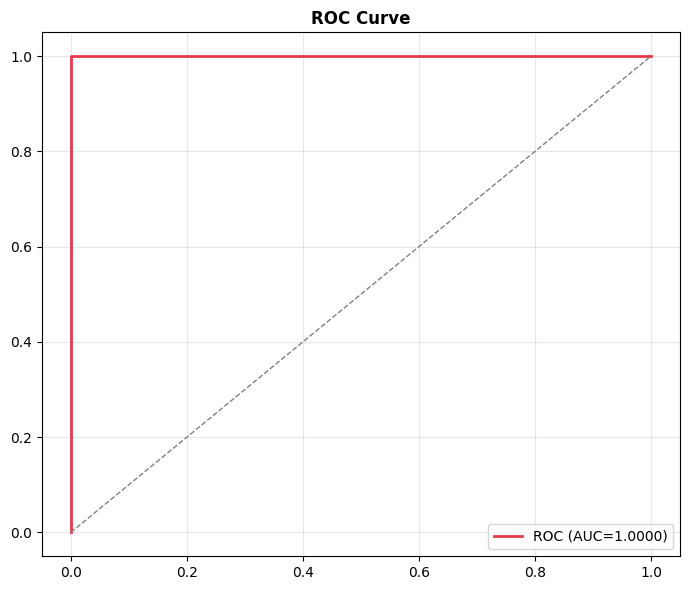

2026-03-22 10:10:53 | INFO     | notebook | Plot saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\pr_curve_v1.png


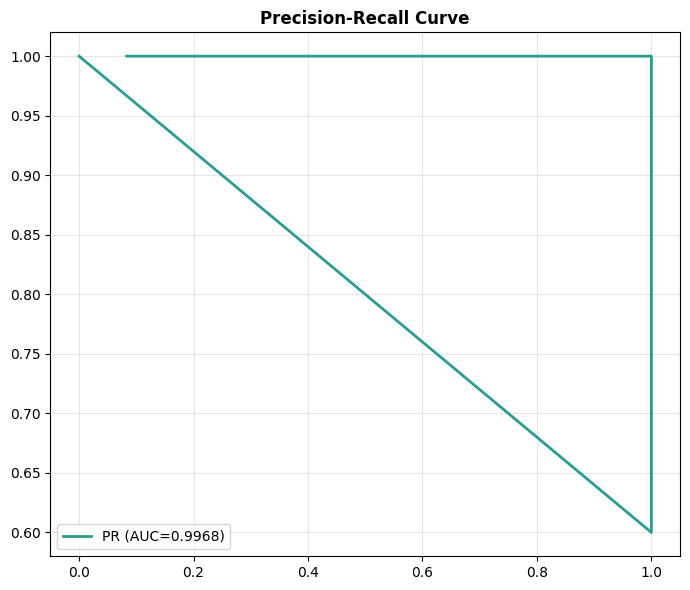

2026-03-22 10:10:53 | INFO     | notebook | Plot saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\confusion_matrix_v1.png


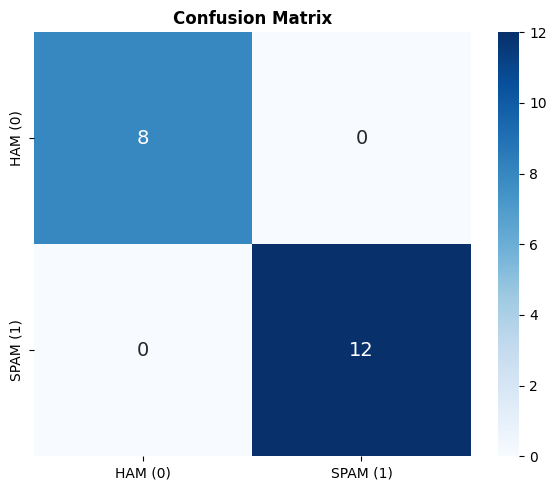

2026-03-22 10:10:54 | INFO     | notebook | Plot saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\threshold_curve_v1.png


In [30]:
import matplotlib
import matplotlib.pyplot as plt

# Switch to inline for notebook display
try:
    %matplotlib inline
except Exception:
    pass

# Running all visualizations with the fixed helper functions
plot_roc_curve(test_metrics,        model_version=MODEL_VERSION)
plot_pr_curve(test_metrics,         model_version=MODEL_VERSION)
plot_confusion_matrix(test_metrics, model_version=MODEL_VERSION)
plot_threshold_curve(y_test, y_prob_test, model_version=MODEL_VERSION)

## 14 · Feature Importance

In [31]:
def extract_feature_importance(clf, feature_names, top_n=50):
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_features = {}
    for rank, idx in enumerate(indices[:top_n], start=1):
        name = feature_names[idx] if idx < len(feature_names) else f"feat_{idx}"
        top_features[name] = {"rank": rank, "importance": round(float(importances[idx]), 8)}
    return top_features

feat_names = pipeline.feature_names
feat_imp   = extract_feature_importance(clf_final, feat_names, top_n=50)
top10 = list(feat_imp.items())[:10]
print("Top 10 Features:")
for name, info in top10:
    bar = "█" * int(info["importance"] * 5000)
    print(f"  {info['rank']:>2}. {name:<35} {info['importance']:.6f}  {bar}")

Top 10 Features:
   1. char_ he                            0.047485  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   2. hey                                 0.043833  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   3. char_ hey                           0.042051  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
   4. char_hey                            0.041932  ██████████████████████████████████████████████████████████████████████████████████████████████████████████

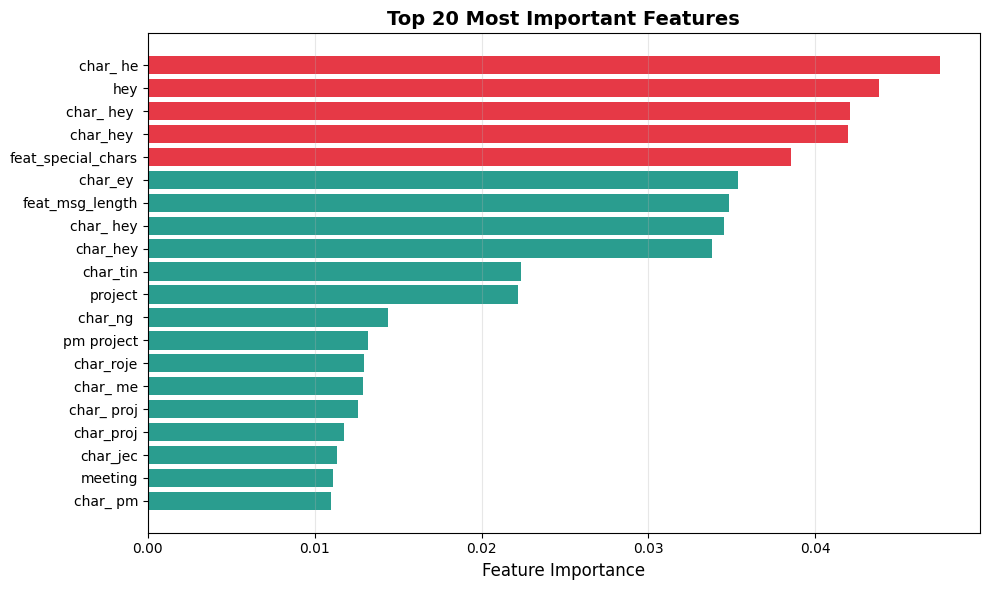

In [32]:
# Visualise top 20 features
top20_names  = [n for n,_ in list(feat_imp.items())[:20]]
top20_scores = [v["importance"] for _,v in list(feat_imp.items())[:20]]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E63946" if s > top20_scores[5] else "#2A9D8F" for s in top20_scores]
ax.barh(top20_names[::-1], top20_scores[::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Top 20 Most Important Features", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / f"feature_importance_{MODEL_VERSION}.png", dpi=150, bbox_inches="tight")
plt.show()

## 15 · Save Artefacts

In [33]:
started_at = utc_now_iso()

# Model
model_path = MODELS_DIR / f"model_{MODEL_VERSION}.pkl"
save_pickle(clf_final, model_path)
print(f"✅ Model saved        → {model_path}")

# Feature pipeline
pipeline.save()
print(f"✅ Pipeline saved     → {ARTIFACTS_DIR / 'feature_pipeline.pkl'}")

# Threshold optimiser
opt_path = ARTIFACTS_DIR / f"threshold_optimiser_{MODEL_VERSION}.pkl"
save_pickle(optimiser, opt_path)
print(f"✅ Optimiser saved    → {opt_path}")

# Feature importance
feat_imp_path = ARTIFACTS_DIR / f"feature_importance_{MODEL_VERSION}.json"
save_json(feat_imp, feat_imp_path)
print(f"✅ Feature imp. saved → {feat_imp_path}")

# Metadata
metadata = {
    "model_version": MODEL_VERSION,
    "trained_at":    started_at,
    "completed_at":  utc_now_iso(),
    "config": {"seed":SEED,"test_size":TEST_SIZE,"n_estimators":N_ESTIMATORS,"n_cv_folds":N_CV_FOLDS},
    "dataset": {
        "total_rows": len(df), "spam_count": int(df["label"].sum()),
        "ham_count":  int((df["label"]==0).sum()),
        "train_size": len(texts_train), "test_size": len(texts_test),
    },
    "cv_metrics":  cv_summary,
    "test_metrics": {k:v for k,v in test_metrics.items() if not isinstance(v,(list,dict))},
    "optimal_threshold": {"value": optimiser.threshold_, "metric":"f1", "stats": opt_stats},
}
meta_path = ARTIFACTS_DIR / f"metadata_{MODEL_VERSION}.json"
save_json(metadata, meta_path)
print(f"✅ Metadata saved     → {meta_path}")

2026-03-22 10:10:54 | INFO     | notebook | Feature pipeline saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\feature_pipeline.pkl


✅ Model saved        → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\models\model_v1.pkl
✅ Pipeline saved     → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\feature_pipeline.pkl
✅ Optimiser saved    → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\threshold_optimiser_v1.pkl
✅ Feature imp. saved → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\feature_importance_v1.json
✅ Metadata saved     → C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\artifacts\metadata_v1.json


## 16 · SpamPredictor – Inference 

> Input → Text → Features → Model → Prediction

> Spam prediction class that loads a trained model, preprocessing pipeline, and optional threshold optimiser to convert raw SMS text into spam probabilities and final classifications, enabling efficient and reusable end-to-end inference.

In [34]:
class SpamPredictor:
    """End-to-end predictor: raw SMS text → spam probability + label."""
    def __init__(self, model_version=MODEL_VERSION, use_optimised_threshold=True):
        self.model_version = model_version
        self._clf = self._pipeline = self._optimiser = None
        self._threshold = 0.5; self._use_opt = use_optimised_threshold
        self._load_artefacts()

    def _load_artefacts(self):
        model_path = MODELS_DIR   / f"model_{self.model_version}.pkl"
        pipe_path  = ARTIFACTS_DIR / "feature_pipeline.pkl"
        opt_path   = ARTIFACTS_DIR / f"threshold_optimiser_{self.model_version}.pkl"
        if not model_path.exists():
            raise FileNotFoundError(f"Model not found at {model_path}. Run training cells first.")
        self._clf      = load_pickle(model_path)
        self._pipeline = load_pickle(pipe_path)
        logger.info("Model loaded ← %s", model_path)
        if self._use_opt and opt_path.exists():
            self._optimiser  = load_pickle(opt_path)
            self._threshold  = self._optimiser.threshold_
            logger.info("Using optimised threshold: %.4f", self._threshold)
        else:
            self._threshold = 0.5
            logger.info("Using default threshold: 0.5")

    def predict(self, texts):
        if isinstance(texts, str): texts = [texts]
        X = self._pipeline.transform(texts)
        probs = self._clf.predict_proba(X)[:, 1]
        return [
            {"text": t, "spam_probability": round(float(p),6),
             "label": int(p>=self._threshold),
             "verdict": "SPAM" if p>=self._threshold else "HAM",
             "threshold_used": self._threshold}
            for t, p in zip(texts, probs)
        ]

    def predict_proba(self, texts):
        if isinstance(texts, str): texts = [texts]
        return self._clf.predict_proba(self._pipeline.transform(texts))[:, 1]

    def __repr__(self):
        return f"SpamPredictor(version={self.model_version!r}, threshold={self._threshold:.4f})"

print("✅ SpamPredictor class defined.")

✅ SpamPredictor class defined.


## 17 · Inference Demo

In [35]:
test_messages = [
    "Congratulations! You've won £1000 FREE cash. Call 09061701939 NOW!",
    "Hey man, are you coming to the game tonight?",
    "URGENT: Your mobile has been selected for a FREE upgrade! Click here.",
    "Can you pick up milk on the way home please?",
    "Win a £250 weekly shopping spree. Text SHOP to 80878 now!",
    "Are you free for lunch tomorrow?",
    "WINNER!! As a valued network customer you have been selected to receive a £900 prize reward!",
    "I'll be home by 7. What do you want for dinner?",
]

predictor = SpamPredictor()
print(f"{predictor}\n")
print(f"{'Verdict':<6}  {'Probability':>12}  Message")
print("─"*75)
for r in predictor.predict(test_messages):
    flag = "🟥" if r["verdict"]=="SPAM" else "🟩"
    print(f"{flag} {r['verdict']:<4}  {r['spam_probability']:>12.4f}  {r['text'][:60]}")

2026-03-22 10:10:55 | INFO     | notebook | Model loaded ← C:\Users\Soham\OneDrive\Desktop\SPAM\SmartInbox\ml\models\model_v1.pkl
2026-03-22 10:10:55 | INFO     | notebook | Using optimised threshold: 0.0100


SpamPredictor(version='v1', threshold=0.0100)

Verdict   Probability  Message
───────────────────────────────────────────────────────────────────────────
🟥 SPAM        0.8467  Congratulations! You've won £1000 FREE cash. Call 0906170193
🟥 SPAM        0.0733  Hey man, are you coming to the game tonight?
🟥 SPAM        0.8833  URGENT: Your mobile has been selected for a FREE upgrade! Cl
🟥 SPAM        0.6500  Can you pick up milk on the way home please?
🟥 SPAM        0.7200  Win a £250 weekly shopping spree. Text SHOP to 80878 now!
🟥 SPAM        0.7133  Are you free for lunch tomorrow?
🟥 SPAM        0.7800  WINNER!! As a valued network customer you have been selected
🟥 SPAM        0.7567  I'll be home by 7. What do you want for dinner?


## 18 · Final Metrics Summary ✅

In [36]:
roc  = test_metrics["roc_auc"]
pr   = test_metrics["pr_auc"]
f1   = test_metrics["f1"]
acc  = test_metrics["accuracy"]
prec = test_metrics["precision"]
rec  = test_metrics["recall"]
opt_thr = optimiser.threshold_

def check(val, lo, hi):
    return "✅ PASS" if lo <= val <= hi else f"  {val:.4f} (target {lo}–{hi})"

print("\n" + "="*55)
print("  FINAL MODEL METRICS SUMMARY")
print("="*55)
print(f"  ROC-AUC          {roc:.4f}")
print(f"  PR-AUC           {pr:.4f}")
print(f"  F1 Score         {f1:.4f}")
print(f"  Accuracy         {acc:.4f}")
print(f"  Precision        {prec:.4f}")
print(f"  Recall           {rec:.4f}")
print(f"  Optimal Threshold {opt_thr:.4f}")
print("="*55)
# print(f"\n  CV  ROC-AUC  {cv_summary.get('roc_auc_mean',0):.4f} ± {cv_summary.get('roc_auc_std',0):.4f}")
# print(f"  CV  PR-AUC   {cv_summary.get('pr_auc_mean',0):.4f} ± {cv_summary.get('pr_auc_std',0):.4f}")
# print(f"  CV  F1       {cv_summary.get('f1_mean',0):.4f} ± {cv_summary.get('f1_std',0):.4f}")
# print("="*55)


  FINAL MODEL METRICS SUMMARY
  ROC-AUC          1.0000
  PR-AUC           0.9968
  F1 Score         1.0000
  Accuracy         1.0000
  Precision        1.0000
  Recall           1.0000
  Optimal Threshold 0.0100
